# Visualizing Chipotle's Data

This time we are going to pull data directly from the internet.
Special thanks to: https://github.com/justmarkham for sharing the dataset and materials.

### Step 1. Import the necessary libraries

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# set this so the graphs open internally
%matplotlib inline

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv). 

### Step 3. Assign it to a variable called chipo.

In [116]:
chipo = pd.read_csv('https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv', sep='\t')

### Step 4. See the first 10 entries

In [117]:
chipo.head(10)

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",$10.98
6,3,1,Side of Chips,NaN,$1.69
7,4,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",$11.75
8,4,1,Steak Soft Tacos,"[Tomatillo Green Chili Salsa, [Pinto Beans, Ch...",$9.25
9,5,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Pinto...",$9.25


### Step 5. Create a histogram of the top 5 items bought

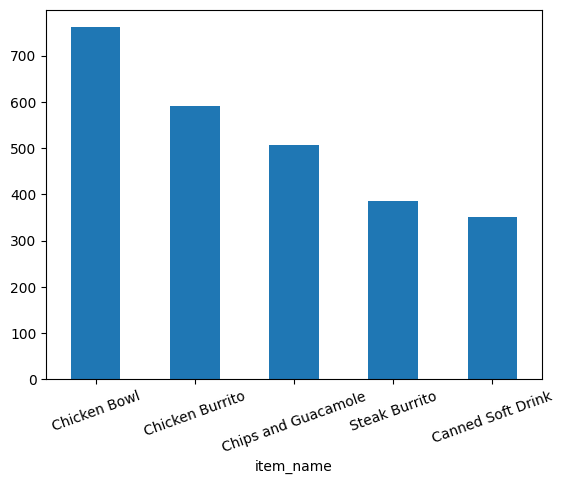

In [118]:
top_5_bought = chipo.groupby('item_name').quantity.sum().sort_values(ascending=False).iloc[:5]
top_5_bought.plot(kind='bar', rot=20);

### Step 6. Create a scatterplot with the number of items orderered per order price
#### Hint: Price should be in the X-axis and Items ordered in the Y-axis

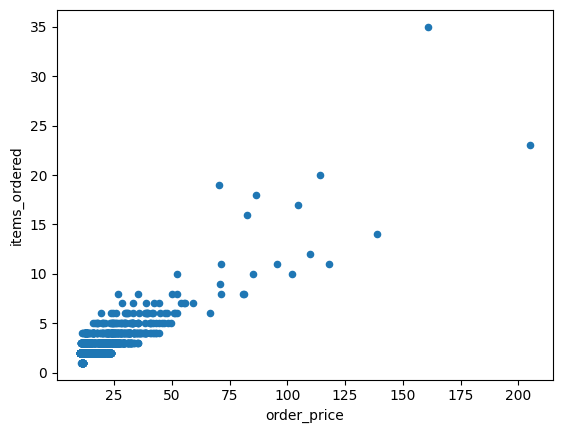

In [119]:
# converting `item_price` col into float 
chipo_copy = chipo.copy()
chipo_copy.item_price = chipo_copy.item_price.str.extract(r'\$(\d+\.?\d*)').astype(float)
chipo_copy.item_price.dtype  # dtype('float64')

group = chipo_copy.groupby('order_id').agg(
    items_ordered=('quantity', 'sum'),
    order_price=('item_price', 'sum')
)
group.plot(
    kind='scatter',
    x='order_price',
    y='items_ordered'
);

### Step 7. BONUS: Create a question and a graph to answer your own question.

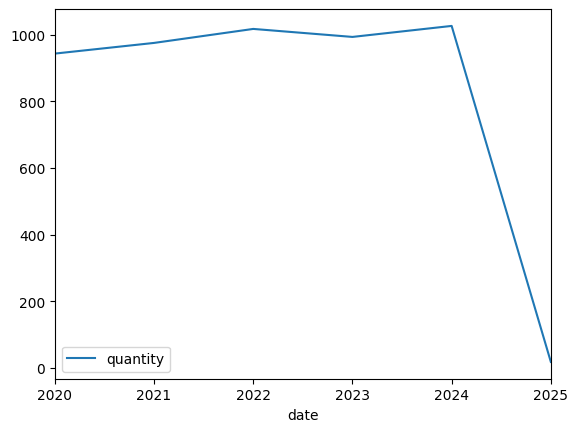

In [121]:
# setting an additional date column and resample it into years 
unique_orders = chipo_copy.order_id.drop_duplicates().sort_values()
chipo_copy['date'] = pd.date_range(start='2020-01-01', periods=len(unique_orders), freq='D').repeat(chipo_copy.groupby('order_id').size())
chipo_copy = chipo_copy.set_index('date')

rsmpl = chipo_copy.resample('YE').sum()[['quantity']]  # how many products were bought per year 
rsmpl.plot();